In [167]:
import numpy as np
import matplotlib.pyplot as plt


In [168]:
def f_true(x):
    return 0.03 * x ** 4 - 0.4 * x ** 2 + 0.7 * np.sin(2.2 * x)

def make_poly_features(x, degree):
    x = np.asarray(x).reshape(-1, 1)
    X = np.hstack([x ** i for i in range(degree + 1)])
    return X

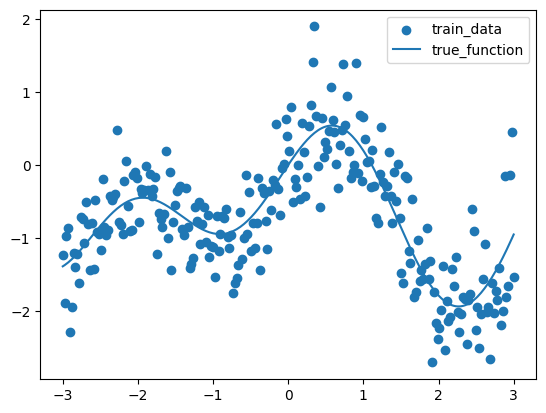

In [169]:
rng = np.random.default_rng(42)

N = 250
x = np.linspace(-3, 3, N)

sigma = 0.5
y = f_true(x) + rng.normal(0, sigma, size=x.shape)

degree = 15
X = make_poly_features(x, degree)

plt.scatter(x, y, label='train_data')
plt.plot(x, f_true(x), label='true_function')
plt.legend()
plt.show()

In [170]:
lamb = 1.0
alpha = 1.0 / (sigma ** 2)

M = X.shape[1]
posterior_cov_inv = lamb * np.eye(M) + alpha * (X.T @ X)

In [171]:
posterior_cov = np.linalg.inv(posterior_cov_inv)
mean = alpha * posterior_cov @ (X.T @ y)

In [172]:
x_new = np.linspace(-3, 3, 400)
X_new = make_poly_features(x_new, degree)

mean_pred = X_new @ mean
var_pred = 1.0 / alpha + np.sum(X_new @ posterior_cov @ X_new.T, axis=1)
std_pred = np.sqrt(var_pred)

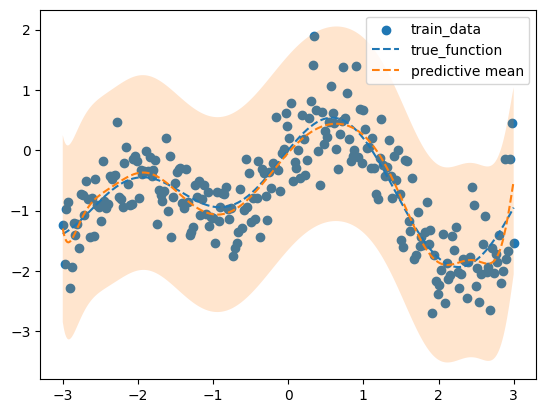

In [173]:
plt.scatter(x, y, label='train_data')
plt.plot(x_new, f_true(x_new), linestyle='--', label='true_function')
plt.plot(x_new, mean_pred, linestyle='--', label='predictive mean')

plt.fill_between(x_new, mean_pred - 2 * std_pred, mean_pred + 2 * std_pred, alpha=0.2)

plt.legend()
plt.show()

In [186]:
def log_evidence(lamb, Xs, y, alpha):
    N = Xs.shape[0]
    sigma2 = 1.0 / alpha
    tau2   = sigma2 / lamb
    C = sigma2 * np.eye(N) + tau2 * (Xs @ Xs.T)

    eps = 1e-12 * float(np.trace(C)) / N
    C = C + eps * np.eye(N)

    L = np.linalg.cholesky(C)
    logdetC = 2.0 * np.sum(np.log(np.diag(L)))   # log|C|
    z = np.linalg.solve(L, y)
    quad = z @ z
    return -0.5 * (N * np.log(2*np.pi) + logdetC + quad)



Лучшая λ: 0.0200395, log-evidence = -205.392


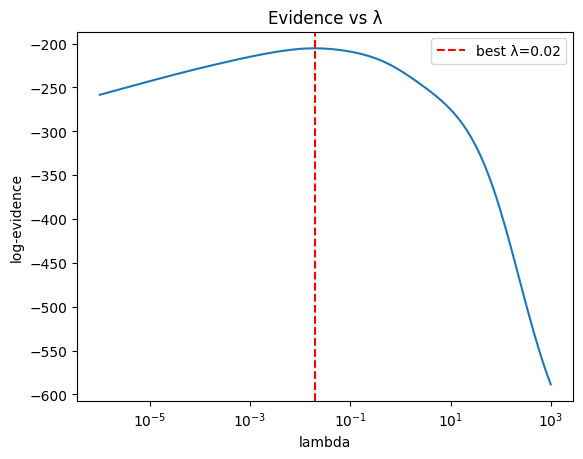

In [187]:
lambdas = np.logspace(-6, 3, 160)
log_evs = np.array([log_evidence(lmb, X_ev, y, alpha) for lmb in lambdas])

best_idx   = int(np.nanargmax(log_evs))
best_lamb  = float(lambdas[best_idx])
best_logev = float(log_evs[best_idx])

print(f"Лучшая λ: {best_lamb:.6g}, log-evidence = {best_logev:.3f}")

plt.figure()
plt.semilogx(lambdas, log_evs)
plt.axvline(best_lamb, color='r', linestyle='--', label=f'best λ={best_lamb:.3g}')
plt.xlabel('lambda'); plt.ylabel('log-evidence')
plt.title('Evidence vs λ')
plt.legend(); plt.show()



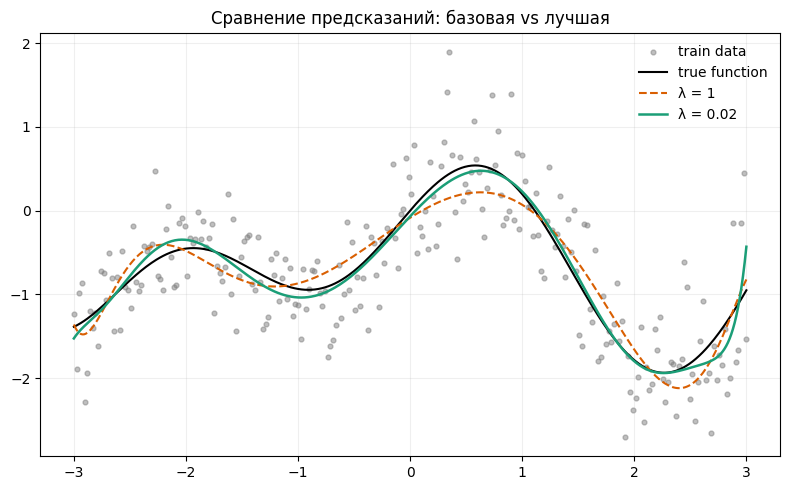

In [188]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=12, color='gray', alpha=0.5, label='train data')
plt.plot(x_new, f_true(x_new), color='black', linewidth=1.5, label='true function')
plt.plot(x_new, mean_pred_base, linestyle='--', color='#d95f02',
         linewidth=1.5, label='λ = 1')
plt.plot(x_new, mean_pred_best, linestyle='-', color='#1b9e77',
         linewidth=1.8, label=f'λ = {best_lamb:.3g}')

plt.title('Сравнение предсказаний: базовая vs лучшая', fontsize=12)
plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
